In [1]:
import os

folder_name = "BayOfBengal_Profiles"
folder_path = rf"C:\INCOIS\ARGO\DATA\{folder_name}"

os.makedirs(folder_path, exist_ok=True)

print("Folder created:", folder_path)

Folder created: C:\INCOIS\ARGO\DATA\BayOfBengal_Profiles


In [2]:
import pandas as pd

file_path = r"C:\INCOiS\ARGO\DATA\Raw_Data\ar_index_global_prof.txt"

df = pd.read_csv(file_path, comment="#")

print(df.head())

                                file          date  latitude  longitude ocean  \
0  aoml/13857/profiles/D13857_001.nc  1.997073e+13     0.267    -16.032     A   
1  aoml/13857/profiles/D13857_002.nc  1.997081e+13     0.072    -17.659     A   
2  aoml/13857/profiles/D13857_003.nc  1.997082e+13     0.543    -19.622     A   
3  aoml/13857/profiles/D13857_004.nc  1.997083e+13     1.256    -20.521     A   
4  aoml/13857/profiles/D13857_005.nc  1.997091e+13     0.720    -20.768     A   

   profiler_type institution     date_update  
0            845          AO  20260220143529  
1            845          AO  20260220143529  
2            845          AO  20260220143530  
3            845          AO  20260220143530  
4            845          AO  20260220143530  


In [3]:
print(df.columns)

Index(['file', 'date', 'latitude', 'longitude', 'ocean', 'profiler_type',
       'institution', 'date_update'],
      dtype='object')


In [4]:
date=df['date'].values
print(date)
longitude = df['longitude'].values
print(longitude)
latitude=df['latitude'].values
print(latitude)
institution=df['institution'].values
print(institution)
ocean=df['ocean'].values
print(ocean)

[1.99707292e+13 1.99708092e+13 1.99708202e+13 ... 2.01305210e+13
 2.01305310e+13 2.01306100e+13]
[-16.032 -17.659 -19.622 ... 138.677 138.465 138.09 ]
[ 0.267  0.072  0.543 ... 27.692 27.895 27.931]
['AO' 'AO' 'AO' ... 'NM' 'NM' 'NM']
['A' 'A' 'A' ... 'P' 'P' 'P']


In [5]:

ocean_df=df[df['ocean']=='I']
print(ocean_df.head())
print(ocean_df['ocean'])

                                       file          date  latitude  \
1695  aoml/1900042/profiles/D1900042_001.nc  2.002113e+13   -45.966   
1696  aoml/1900042/profiles/D1900042_002.nc  2.002121e+13   -45.755   
1697  aoml/1900042/profiles/D1900042_003.nc  2.002122e+13   -45.618   
1698  aoml/1900042/profiles/D1900042_004.nc  2.002123e+13   -45.588   
1699  aoml/1900042/profiles/D1900042_005.nc  2.003011e+13   -45.637   

      longitude ocean  profiler_type institution     date_update  
1695     51.947     I            846          AO  20150227132442  
1696     51.582     I            846          AO  20150227132442  
1697     51.514     I            846          AO  20150227132442  
1698     51.548     I            846          AO  20150227132442  
1699     51.507     I            846          AO  20150227132443  
1695       I
1696       I
1697       I
1698       I
1699       I
          ..
3350824    I
3350825    I
3350826    I
3350827    I
3350828    I
Name: ocean, Length: 640766,

enter size of grid 5


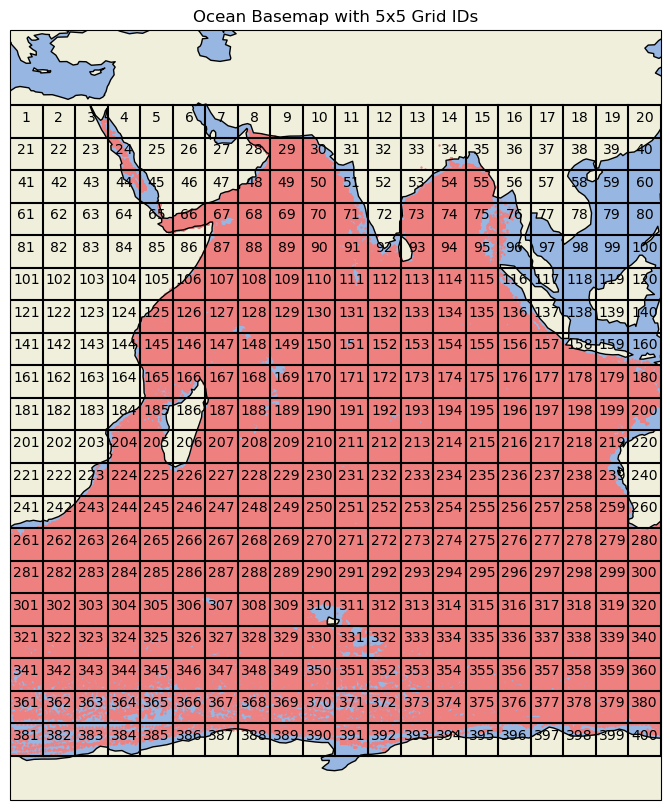

In [6]:
import matplotlib.pyplot as plt
import numpy as np
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Map boundaries
lon_min, lon_max = 20, 120
lat_min, lat_max = -70,30

g_size=int(input("enter size of grid"))
rows=(lat_max-lat_min)/g_size
cols=(lon_max-lon_min)/g_size
rows=int(rows)
cols=int(cols)

# Create grid lines
lon_lines = np.linspace(lon_min, lon_max, cols + 1)
lat_lines = np.linspace(lat_min, lat_max, rows + 1)

# Create figure
fig = plt.figure(figsize=(15,10))

# Create map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Add ocean and land
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)

# Add coastlines
ax.coastlines()

# Draw vertical grid lines
for lon in lon_lines:
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='black',
        transform=ccrs.PlateCarree()
    )

# Draw horizontal grid lines
for lat in lat_lines:
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='black',
        transform=ccrs.PlateCarree()
    )

# Add grid IDs
grid_id = 1

for i in reversed(range(rows)):
    for j in range(cols):

        # Grid center
        x_center = (lon_lines[j] + lon_lines[j+1]) / 2
        y_center = (lat_lines[i] + lat_lines[i+1]) / 2

        # Add text label
        ax.text(
            x_center,
            y_center,
            f"{grid_id}",
            transform=ccrs.PlateCarree(),
            ha='center',
            fontsize=10,
            color='black'
        )

        grid_id += 1
ax.scatter(
    ocean_df['longitude'],
    ocean_df['latitude'],
    s=0.5,

    color='lightcoral',
    transform=ccrs.PlateCarree()   # ✅ Correct
)

# Add title
plt.title("Ocean Basemap with 5x5 Grid IDs")

# Show map
plt.show()

In [13]:
import numpy as np
ocean_df = ocean_df.copy()
# Grid size
g_size = 5

ocean_df['grid_col'] = (
    ((ocean_df['longitude'] - lon_min) // g_size).astype(int)

)

ocean_df['grid_row'] = (
    ((lat_max - ocean_df['latitude']) // g_size).astype(int)

)
ocean_df['grid_id'] = (
    ocean_df['grid_row'] * cols
    + ocean_df['grid_col']
    + 1)

grid7 = ocean_df[ocean_df['grid_id'] == 7]

print(grid7)
grid_profiles = dict(tuple(ocean_df.groupby('grid_id')))
profile_count = ocean_df.groupby('grid_id').size()

print(profile_count)
grid7 = ocean_df[ocean_df['grid_id'] == 7]

print(profile_count.head(40))

Empty DataFrame
Columns: [file, date, latitude, longitude, ocean, profiler_type, institution, date_update, grid_col, grid_row, grid_id]
Index: []
grid_id
3      135
4       99
8      682
9       43
24     796
      ... 
401    111
402     23
403     12
404     29
405    185
Length: 325, dtype: int64
grid_id
3      135
4       99
8      682
9       43
24     796
28    4418
29    9609
30    3633
33       2
34     160
35     108
44     436
45     251
47     786
48    3183
49    6242
50    8989
51    1409
53     893
54    6697
55    4398
56       3
65     829
66    2987
67    2206
68    2910
69    5679
70    6858
71    1759
72      43
73    4125
74    8214
75    2998
76     101
86     170
87    2157
88    2187
89    3341
90    4409
91    2369
dtype: int64


In [15]:
grid4= ocean_df[ocean_df['grid_id'] == 4]

print(len(grid4))

99


In [17]:
bob_df = ocean_df[
    (ocean_df["latitude"] >= 5) &
    (ocean_df["latitude"] <= 25) &
    (ocean_df["longitude"] >= 80) &
    (ocean_df["longitude"] <= 100)
]

In [10]:
print("Profiles in Bay of Bengal:", len(bob_df))

Profiles in Bay of Bengal: 36559


In [19]:
print(bob_df.columns.tolist())


['file', 'date', 'latitude', 'longitude', 'ocean', 'profiler_type', 'institution', 'date_update', 'grid_col', 'grid_row', 'grid_id']


In [21]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

base_folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles"

# Filter the dataframe directly using the specified latitude and longitude boundaries
bob_df = ocean_df[
    (ocean_df["latitude"] >= 5) &
    (ocean_df["latitude"] <= 25) &
    (ocean_df["longitude"] >= 80) &
    (ocean_df["longitude"] <= 100)
]

os.makedirs(base_folder, exist_ok=True)

def download_file(file_path, save_folder):
    filename = os.path.basename(file_path)
    save_path = os.path.join(save_folder, filename)

    if os.path.exists(save_path):
        return

    try:
        url = "https://data-argo.ifremer.fr/dac/" + file_path

        r = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=120
        )

        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)

    except Exception as e:
        print(f"Error: {filename}: {e}")

# Process files if data exists within the bounding box
if len(bob_df) > 0:
    grid_folder = os.path.join(base_folder, "bob_coordinates")
    os.makedirs(grid_folder, exist_ok=True)

    files_to_download = bob_df["file"].tolist()

    print(f"Bay of Bengal (5-25N, 80-100E): {len(files_to_download)} files")

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [
            executor.submit(
                download_file,
                file_path,
                grid_folder
            )
            for file_path in files_to_download
        ]

        completed = 0
        for _ in as_completed(futures):
            completed += 1

            if completed % 100 == 0:
                print(f"Progress: {completed}/{len(files_to_download)}")

print("Bay of Bengal download completed")


Bay of Bengal (5-25N, 80-100E): 36559 files
Progress: 100/36559
Progress: 200/36559
Progress: 300/36559
Progress: 400/36559
Progress: 500/36559
Progress: 600/36559
Progress: 700/36559
Progress: 800/36559
Progress: 900/36559
Progress: 1000/36559
Progress: 1100/36559
Progress: 1200/36559
Progress: 1300/36559
Progress: 1400/36559
Progress: 1500/36559
Progress: 1600/36559
Progress: 1700/36559
Progress: 1800/36559
Progress: 1900/36559
Progress: 2000/36559
Progress: 2100/36559
Progress: 2200/36559
Progress: 2300/36559
Progress: 2400/36559
Progress: 2500/36559
Progress: 2600/36559
Progress: 2700/36559
Progress: 2800/36559
Progress: 2900/36559
Progress: 3000/36559
Progress: 3100/36559
Progress: 3200/36559
Progress: 3300/36559
Progress: 3400/36559
Progress: 3500/36559
Progress: 3600/36559
Progress: 3700/36559
Progress: 3800/36559
Progress: 3900/36559
Progress: 4000/36559
Progress: 4100/36559
Progress: 4200/36559
Progress: 4300/36559
Progress: 4400/36559
Progress: 4500/36559
Progress: 4600/36559

In [23]:
import os
import requests

# Set your target directory
save_folder = r"C:\INCOiS\ARGO\DATA\BayOfBengal_Profiles\bob_coordinates"
os.makedirs(save_folder, exist_ok=True)

# List of the files that timed out
failed_files = [
    "D2902280_024.nc",
    "D2902280_025.nc",
    "D2902280_026.nc"
]

# Assuming they belong to the 'aoml' or 'coriolis' dac. 
# If they fail to find, we can dynamically search or try the common dac subfolders.
# Most Indian Ocean '2902280' floats are under 'incois' or 'aoml'. 
# We'll use a placeholder 'incois/' - change this path if your dataframe used a different dac prefix!
dac_subfolder = "incois/2902280/profiles/" 

for filename in failed_files:
    save_path = os.path.join(save_folder, filename)
    
    # Full URL path generation
    # Note: If your dataframe 'file' column contains the full 'dac/...' path, 
    # replace `dac_subfolder + filename` directly with that path string.
    url = f"https://data-argo.ifremer.fr/dac/{dac_subfolder}{filename}"
    
    print(f"Downloading {filename}...")
    try:
        r = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=180
        )
        
        if r.status_code == 200:
            with open(save_path, "wb") as f:
                f.write(r.content)
            print(f"Success: {filename} saved.")
        else:
            print(f"Failed: Server responded with status code {r.status_code}")
            
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

print("Individual file download process complete.")

Success: D2902280_024.nc saved.
Success: D2902280_025.nc saved.
Success: D2902280_026.nc saved.
Individual file download process complete.
